# EEG Motor Imagery Preprocessing with MNE

本 Notebook 展示一个基于 MNE-Python 的 EEG 运动想象信号预处理流程。

## Dataset Source

本项目使用公开数据集：

**EEG Motor Movement/Imagery Dataset v1.0.0**

数据来源：

- PhysioNet
- EEG Motor Movement/Imagery Dataset
- Published: September 9, 2009
- Version: 1.0.0
- Dataset page: https://www.physionet.org/content/eegmmidb/1.0.0/
- DOI: https://doi.org/10.13026/C28G6P

该数据集包含来自受试者的 64 通道 EEG 记录，受试者完成了一系列真实运动和运动想象任务。数据以 EDF+ 格式提供，每个 EEG 通道采样率为 160 Hz，并包含 annotation channel。

## Data Included in This Repository

为了保证本 Notebook 可以直接复现，本仓库只包含本 demo 使用的 3 个 EDF 文件：

```text
data/eegbci_manual/S001/S001R06.edf
data/eegbci_manual/S001/S001R10.edf
data/eegbci_manual/S001/S001R14.edf

##  导入依赖库

这一部分导入本项目需要使用的 Python 包。

其中：

- MNE 用于 EEG 数据读取、预处理和可视化
- NumPy 用于数组处理
- Matplotlib 用于绘图
- Scikit-learn 用于机器学习分类
- CSP 用于提取运动想象 EEG 特征
- LDA 用于二分类
- ## 通用可视化函数

为了方便比较不同处理步骤的变化，这里定义几个通用绘图函数。

后面会用它们对比：

- 原始信号 vs 重参考后信号
- ICA 前 vs ICA 后
- 滤波前 vs 滤波后

In [1]:
from pathlib import Path
import warnings

import numpy as np
import matplotlib.pyplot as plt
import mne

from mne.datasets import eegbci
from mne.io import read_raw_edf
from mne.decoding import CSP

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from IPython.display import Image, display

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

print("MNE version:", mne.__version__)

MNE version: 1.12.1


In [25]:
from IPython.display import Image, display

In [26]:
%matplotlib qt

try:
    mne.viz.set_browser_backend("qt")
    print("MNE browser backend is set to qt.")
except Exception as e:
    print("Could not set MNE browser backend to qt.")
    print("Error:", e)
    print("If needed, install it with:")
    print("conda install -c conda-forge pyqt mne-qt-browser -y")

MNE browser backend is set to qt.


In [16]:
def plot_raw_segment(raw_obj, title, start=20, duration=5, n_channels=20, save_name=None):
    """
    画一段连续 EEG 信号的静态图。
    单位转换为 μV。
    """
    raw_eeg = raw_obj.copy().pick("eeg")

    sfreq = raw_eeg.info["sfreq"]
    start_sample = int(start * sfreq)
    stop_sample = int((start + duration) * sfreq)

    n_channels = min(n_channels, len(raw_eeg.ch_names))
    picks = np.arange(n_channels)

    data = raw_eeg.get_data(picks=picks, start=start_sample, stop=stop_sample) * 1e6
    times = raw_eeg.times[start_sample:stop_sample]

    channel_names = [raw_eeg.ch_names[i] for i in picks]

    offset = 150
    offsets = np.arange(n_channels) * offset

    fig, ax = plt.subplots(figsize=(14, 8))

    for i in range(n_channels):
        ax.plot(times, data[i] + offsets[i], linewidth=0.8)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_names)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("EEG channels")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)

    fig.tight_layout()

    if save_name is not None:
        out_path = RESULTS_DIR / save_name
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Saved to:", out_path)
        print("File exists:", out_path.exists())

    plt.show()


def compare_raw_segments(raw_before, raw_after, before_label, after_label,
                         start=20, duration=5, channel="Cz", save_name=None):
    """
    对比同一通道在处理前后的波形。
    默认看 Cz，因为它在运动想象数据里比较重要。
    """
    before = raw_before.copy().pick("eeg")
    after = raw_after.copy().pick("eeg")

    if channel not in before.ch_names:
        channel = before.ch_names[0]
        print("Requested channel not found. Use:", channel)

    sfreq = before.info["sfreq"]
    start_sample = int(start * sfreq)
    stop_sample = int((start + duration) * sfreq)

    before_data = before.get_data(picks=[channel], start=start_sample, stop=stop_sample)[0] * 1e6
    after_data = after.get_data(picks=[channel], start=start_sample, stop=stop_sample)[0] * 1e6
    times = before.times[start_sample:stop_sample]

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(times, before_data, label=before_label, linewidth=1.0)
    ax.plot(times, after_data, label=after_label, linewidth=1.0, alpha=0.8)

    ax.set_title(f"Before vs After comparison on channel {channel}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (μV)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    if save_name is not None:
        out_path = RESULTS_DIR / save_name
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Saved to:", out_path)
        print("File exists:", out_path.exists())

    plt.show()


def plot_psd_compare(raw_before, raw_after, before_label, after_label,
                     fmin=1, fmax=40, save_name=None):
    """
    对比处理前后的 PSD。
    """
    psd_before = raw_before.copy().pick("eeg").compute_psd(
        fmin=fmin,
        fmax=fmax,
        verbose=False
    )

    psd_after = raw_after.copy().pick("eeg").compute_psd(
        fmin=fmin,
        fmax=fmax,
        verbose=False
    )

    freqs_before = psd_before.freqs
    freqs_after = psd_after.freqs

    data_before = psd_before.get_data().mean(axis=0)
    data_after = psd_after.get_data().mean(axis=0)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(freqs_before, data_before, label=before_label)
    ax.plot(freqs_after, data_after, label=after_label)

    ax.set_title("PSD comparison")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power spectral density")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    if save_name is not None:
        out_path = RESULTS_DIR / save_name
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Saved to:", out_path)
        print("File exists:", out_path.exists())

    plt.show()

## 设置项目路径

这里设置项目文件夹、数据文件夹和结果文件夹。

请确认你的项目路径是：

```text
D:\eeg-motor-imagery-mne-demo

In [4]:
PROJECT_DIR = Path(r"D:\eeg-motor-imagery-mne-demo")

DATASET_DIR = PROJECT_DIR / "data" / "eegbci_manual" / "S001"
RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook current folder:", Path.cwd())
print("Project folder:", PROJECT_DIR)
print("Dataset folder:", DATASET_DIR)
print("Results folder:", RESULTS_DIR)

print("Project exists:", PROJECT_DIR.exists())
print("Dataset folder exists:", DATASET_DIR.exists())
print("Results folder exists:", RESULTS_DIR.exists())

Notebook current folder: D:\eeg-motor-imagery-mne-demo\notebooks
Project folder: D:\eeg-motor-imagery-mne-demo
Dataset folder: D:\eeg-motor-imagery-mne-demo\data\eegbci_manual\S001
Results folder: D:\eeg-motor-imagery-mne-demo\results
Project exists: True
Dataset folder exists: True
Results folder exists: True


##  检查本地 EDF 文件

本项目使用 Subject 1 的三个 imagined movement runs：

- S001R06.edf
- S001R10.edf
- S001R14.edf

这三个 run 对应 imagined both fists vs imagined both feet。

In [5]:
raw_fnames = [
    DATASET_DIR / "S001R06.edf",
    DATASET_DIR / "S001R10.edf",
    DATASET_DIR / "S001R14.edf",
]

for fname in raw_fnames:
    print(fname)
    print("exists:", fname.exists())
    print()

missing_files = [fname for fname in raw_fnames if not fname.exists()]

if missing_files:
    raise FileNotFoundError(f"These EDF files are missing: {missing_files}")
else:
    print("All EDF files found.")

D:\eeg-motor-imagery-mne-demo\data\eegbci_manual\S001\S001R06.edf
exists: True

D:\eeg-motor-imagery-mne-demo\data\eegbci_manual\S001\S001R10.edf
exists: True

D:\eeg-motor-imagery-mne-demo\data\eegbci_manual\S001\S001R14.edf
exists: True

All EDF files found.


## 读取 EDF 文件为 MNE Raw 对象

EDF 是一种常见的生理信号文件格式。

MNE 读取 EDF 后，会得到 Raw 对象。

Raw 可以理解为：

```text
一整段连续 EEG 信号，还没有按照 trial 切分。

In [6]:
raw_files = [
    read_raw_edf(str(fname), preload=True, verbose=False)
    for fname in raw_fnames
]

raw = mne.concatenate_raws(raw_files)

# 标准化 EEGBCI 通道名称
eegbci.standardize(raw)

raw

<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.3 MiB, data loaded>

## 查看 Raw 数据基本信息

这一部分查看 EEG 数据的基本信息，包括：

- 通道数量
- 前几个通道名
- 采样率
- 数据总时长
- annotations 事件标记

在 runs 6、10、14 中：

- T0 = 休息
- T1 = imagined both fists
- T2 = imagined both feet

In [7]:
print(raw)

print("Number of channels:", len(raw.ch_names))
print("First 10 channels:", raw.ch_names[:10])
print("Sampling frequency:", raw.info["sfreq"])
print("Total duration, seconds:", raw.times[-1])

print()
print("Annotations:")
print(raw.annotations)

<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.3 MiB, data loaded>
Number of channels: 64
First 10 channels: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1']
Sampling frequency: 160.0
Total duration, seconds: 374.99375

Annotations:
<Annotations | 94 segments: BAD boundary (2), EDGE boundary (2), T0 (45), ...>


## 比较 standard_1005 和 standard_1020 电极模板

本数据是 64 通道 EEGBCI 数据。

通道名包含 FC1、FC2、C1、C2 等中间电极位置，这些位置更适合使用更密集的 `standard_1005` 模板。

`standard_1020` 是更基础的模板，可能无法覆盖所有通道。

In [9]:
montage_1005 = mne.channels.make_standard_montage("standard_1005")
montage_1020 = mne.channels.make_standard_montage("standard_1020")

missing_1005 = sorted(set(raw.ch_names) - set(montage_1005.ch_names))
missing_1020 = sorted(set(raw.ch_names) - set(montage_1020.ch_names))

print("Number of raw channels:", len(raw.ch_names))
print()
print("Missing channels in standard_1005:")
print(missing_1005)
print()
print("Missing channels in standard_1020:")
print(missing_1020)

Number of raw channels: 64

Missing channels in standard_1005:
[]

Missing channels in standard_1020:
[]


**看来两个模板没有区别**

## 设置 standard_1005 电极位置

这里给 EEG 通道设置标准头皮坐标。

这一步不会改变 EEG 波形数值，只是告诉 MNE 每个电极在头皮上的位置。

后续画 topomap、CSP patterns 时需要这个信息。

In [10]:
raw.set_montage("standard_1005")

print(raw.info)

<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


##  保存原始数据副本

MNE 里的很多操作，例如滤波、重参考、ICA apply，都会直接修改对象本身。

因此这里保留一个原始副本 `raw_original`。

后续所有处理都在副本上完成，避免不可逆操作影响最初读取的数据。

In [ ]:
raw_original = raw.copy().load_data()

print(raw_original)
print("custom_ref_applied:", raw_original.info["custom_ref_applied"])
print("highpass:", raw_original.info["highpass"])
print("lowpass:", raw_original.info["lowpass"])

## 可视化：原始 Raw EEG

这里查看未经重参考、未经滤波、未经 ICA 的原始 EEG 信号。

这是后续所有处理的基准。

In [24]:
%matplotlib qt

raw_original.copy().pick("eeg").plot(
    start=20,
    duration=5,
    n_channels=20,
    scalings="auto",
    block=False
)

<mne_qt_browser._pg_figure.MNEQtBrowser(0x205984fc670) at 0x0000020598F90080>

## 交互式浏览原始 Raw EEG

这一部分使用 MNE 的交互式浏览器查看连续 EEG 信号。

运行后会弹出一个 EEG 浏览窗口。

可以滚动时间轴、查看不同通道的 EEG 波形。

In [12]:
%matplotlib qt

mne.viz.set_browser_backend("qt")

raw_original.copy().pick("eeg").plot(
    duration=5,
    n_channels=20,
    scalings="auto",
    block=False
)

<mne_qt_browser._pg_figure.MNEQtBrowser(0x20583e590e0) at 0x00000205FB415A80>

##  保存 Raw EEG 静态图

这一部分保存一张连续 EEG 信号的静态图片，用于后续放到 GitHub README 中展示。

这里不用 `raw.plot()` 保存图片，而是直接用 matplotlib 绘制前 20 个 EEG 通道的前 5 秒信号。

这样更稳定，不容易被交互式 Qt 窗口影响。

Saved to: D:\eeg-motor-imagery-mne-demo\results\raw_eeg_sample.png
File exists: True
File size: 737082 bytes


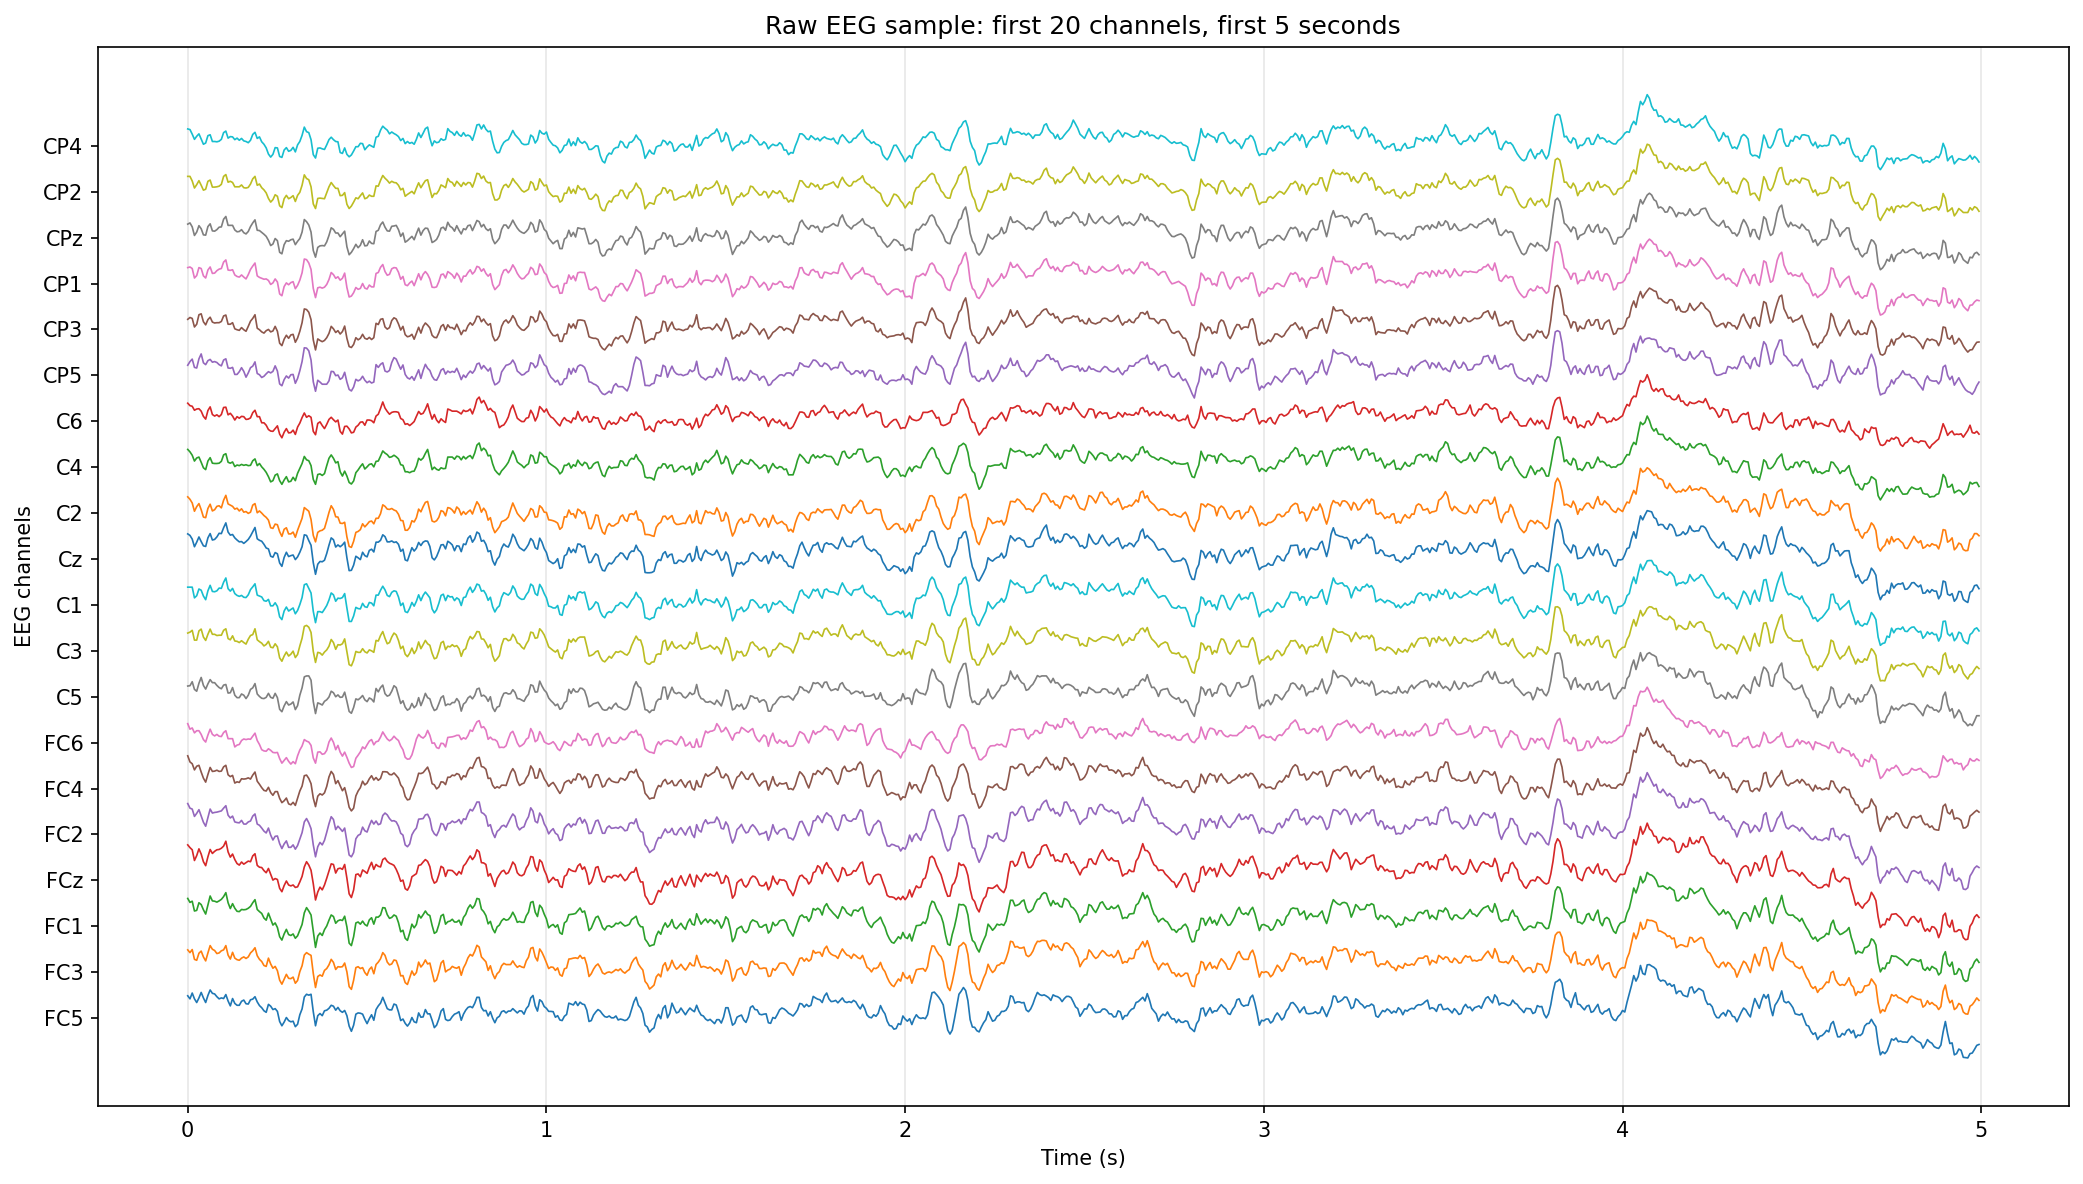

In [13]:
%matplotlib inline

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

raw_eeg = raw_original.copy().pick("eeg")

n_channels_to_plot = 20
duration = 5.0

sfreq = raw_eeg.info["sfreq"]
n_samples = int(duration * sfreq)

picks = np.arange(n_channels_to_plot)

# 单位从 V 转成 μV
data = raw_eeg.get_data(picks=picks, start=0, stop=n_samples) * 1e6
times = raw_eeg.times[:n_samples]

channel_names = [raw_eeg.ch_names[i] for i in picks]

offset = 150
offsets = np.arange(n_channels_to_plot) * offset

fig, ax = plt.subplots(figsize=(14, 8))

for i in range(n_channels_to_plot):
    ax.plot(times, data[i] + offsets[i], linewidth=0.8)

ax.set_yticks(offsets)
ax.set_yticklabels(channel_names)
ax.set_xlabel("Time (s)")
ax.set_ylabel("EEG channels")
ax.set_title("Raw EEG sample: first 20 channels, first 5 seconds")
ax.grid(True, axis="x", alpha=0.3)

fig.tight_layout()

raw_plot_path = RESULTS_DIR / "raw_eeg_sample.png"

fig.savefig(raw_plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print("Saved to:", raw_plot_path)
print("File exists:", raw_plot_path.exists())

if raw_plot_path.exists():
    print("File size:", raw_plot_path.stat().st_size, "bytes")
    display(Image(filename=str(raw_plot_path)))
else:
    print("Save failed. Please check RESULTS_DIR:", RESULTS_DIR)

## 平均参考

EEG 是相对电位，必须有参考点。

这里使用平均参考，把所有 EEG 通道的平均值作为参考。

为了保护原始数据，这一步在 `raw_ref` 副本上完成。

`raw_original` 不会被修改。

In [14]:
raw_ref = raw_original.copy().load_data()

raw_ref.set_eeg_reference(
    ref_channels="average",
    projection=False
)

print(raw_ref)
print("custom_ref_applied:", raw_ref.info["custom_ref_applied"])

<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>
custom_ref_applied: 1 (FIFFV_MNE_CUSTOM_REF_ON)


## 对比：重参考前 vs 重参考后

这里选择 Cz 通道，对比平均参考前后的波形变化。

Saved to: D:\eeg-motor-imagery-mne-demo\results\03_reference_comparison_cz.png
File exists: True


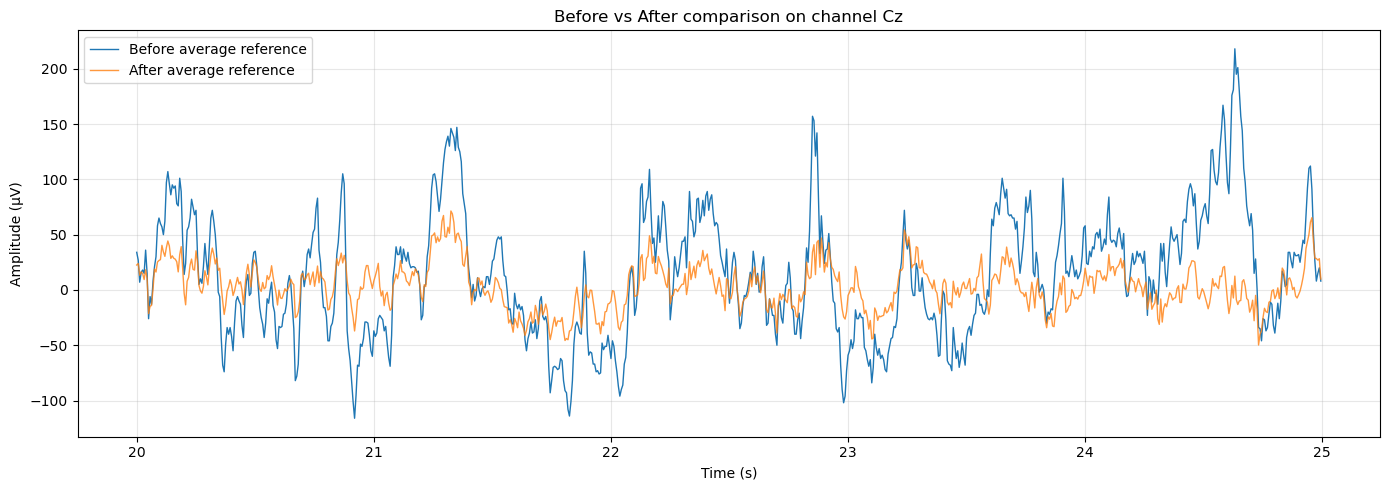

In [18]:
%matplotlib inline

compare_raw_segments(
    raw_original,
    raw_ref,
    before_label="Before average reference",
    after_label="After average reference",
    start=20,
    duration=5,
    channel="Cz",
    save_name="03_reference_comparison_cz.png"
)

Saved to: D:\eeg-motor-imagery-mne-demo\results\04_reference_psd_comparison.png
File exists: True


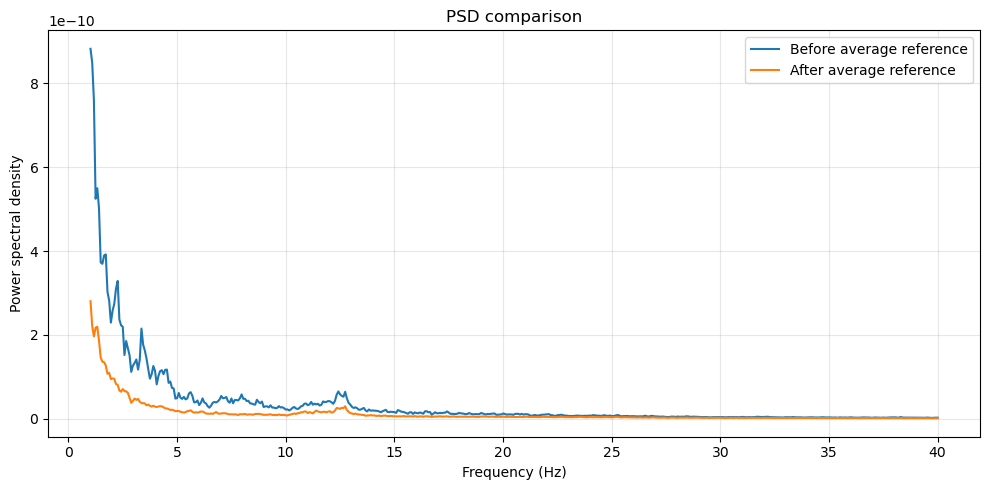

In [19]:
%matplotlib inline

plot_psd_compare(
    raw_original,
    raw_ref,
    before_label="Before average reference",
    after_label="After average reference",
    fmin=1,
    fmax=40,
    save_name="04_reference_psd_comparison.png"
)

In [28]:
raw_ref = raw_original.copy().load_data()

raw_ref.set_eeg_reference(
    ref_channels="average",
    projection=False
)

print(raw_ref)
print("custom_ref_applied:", raw_ref.info["custom_ref_applied"])

<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>
custom_ref_applied: 1 (FIFFV_MNE_CUSTOM_REF_ON)


## 交互式双窗口对比：重参考前 vs 重参考后

这里会打开两个独立 EEG 浏览窗口：

- 重参考前：`raw_original`
- 重参考后：`raw_ref`

请把两个窗口手动拖到左右并排，动态查看平均参考前后的变化。

说明：

- 处理本身作用于完整数据
- 窗口只是从指定时间点开始显示一小段
- 你可以在窗口里滚动浏览全程

In [30]:
%matplotlib qt

raw_original.copy().pick("eeg").plot(
    start=100,
    duration=5,
    n_channels=20,
    scalings="auto",
    block=False,
    title="重参考前：raw_original"
)

raw_ref.copy().pick("eeg").plot(
    start=100,
    duration=5,
    n_channels=20,
    scalings="auto",
    block=False,
    title="重参考后：raw_ref"
)

print("重参考前后两个交互窗口已打开。请手动拖到左右并排对比。")

重参考前后两个交互窗口已打开。请手动拖到左右并排对比。


## 可选步骤：ICA 伪迹检查

ICA 用于检查可能的伪迹成分，例如眨眼、眼动或肌电。

本项目中 ICA 是可选步骤。

如果不想使用 ICA，设置：

`USE_ICA = False`

如果启用 ICA，但没有发现需要删除的成分，就保持：

`ICA_EXCLUDE = []`

如果发现明显伪迹成分，例如第 0 和第 2 个成分，就改成：

`ICA_EXCLUDE = [0, 2]`

In [31]:
# 是否启用 ICA
USE_ICA = True

print("USE_ICA:", USE_ICA)

USE_ICA: True


## 为 ICA 准备 1 Hz 高通副本

ICA 拟合前通常需要 1 Hz 高通，以减少低频漂移对 ICA 的影响。

这份数据只用于拟合 ICA，不作为最终分类数据。

In [21]:
if USE_ICA:
    raw_for_ica = raw_ref.copy().load_data()

    raw_for_ica.filter(
        l_freq=1.0,
        h_freq=None,
        fir_design="firwin",
        skip_by_annotation="edge",
        verbose=True
    )

    print(raw_for_ica)
else:
    raw_for_ica = None
    print("ICA disabled.")

Filtering raw data in 3 contiguous segments
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 529 samples (3.306 s)

<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>


## 拟合 ICA

这里使用 ICA 对 EEG 信号进行独立成分分解。

本数据是 EEGBCI 数据，没有单独的 EOG 通道，因此不能完全依赖自动眼动检测。

这里采用人工检查方式：

1. 查看 ICA 成分的空间分布
2. 查看 ICA 成分的时间序列
3. 通过鼠标点击选择明显伪迹成分
4. 将选择结果保存到 `ica.exclude`

In [32]:
if USE_ICA:
    ica = mne.preprocessing.ICA(
        n_components=20,
        method="fastica",
        random_state=97,
        max_iter="auto"
    )

    ica.fit(
        raw_for_ica,
        picks="eeg",
        decim=3
    )

    print(ica)
else:
    ica = None
    print("ICA disabled.")

<ICA | raw data decomposition, method: fastica (fit in 42 iterations on 20000 samples), 20 ICA components (64 PCA components available), channel types: eeg, no sources marked for exclusion>


## 查看 ICA 成分空间分布

这里打开 ICA components 拓扑图。

每一个小图对应一个 ICA 成分，例如：

- ICA000
- ICA001
- ICA002

观察重点：

- 如果某个成分主要集中在额部，可能与眨眼或眼动有关
- 如果某个成分呈现非常局部、异常的高频模式，可能是肌电或噪声
- 如果不确定，不要删除

这个图用于辅助判断，真正选择排除成分建议在下一步 `plot_sources` 中完成。

In [36]:
%matplotlib qt

if USE_ICA:
    ica.plot_components(
        inst=raw_for_ica,
        show=True
    )
else:
    print("ICA disabled.")

## 通过鼠标点击选择需要排除的 ICA 成分

这里打开 ICA sources 交互窗口。

操作方法：

1. 查看每个 ICA 成分的时间序列
2. 如果某个成分明显像眨眼、眼动、肌电或异常噪声，点击该成分对应的线或标签
3. 被点击选中的成分会加入 `ica.exclude`
4. 如果点错了，可以再次点击取消
5. 关闭窗口后，运行下一格查看选择结果

注意：

这里点击选择的是 **ICA 成分编号**，不是 EEG 通道名。

例如你选择了 ICA000 和 ICA002，关闭窗口后会得到：

```python
ica.exclude = [0, 2]

In [37]:
## Code 单元格：打开 ICA sources 并点击选择

%matplotlib qt

if USE_ICA:
    ica.plot_sources(
        raw_for_ica,
        block=True
    )
else:
    print("ICA disabled.")

## 查看鼠标选择的 ICA 成分

关闭 ICA sources 窗口后，运行这一格。

如果你刚才点击选择了某些 ICA 成分，这里会显示对应的编号。

例如：

```python
Selected ICA components: [0, 2]
ICA_EXCLUDE = [0, 2]

In [38]:
ICA_EXCLUDE = []

In [39]:
## Code 单元格：打印 ICA 选择结果

if USE_ICA:
    print("Selected ICA components:", ica.exclude)
    print("Copy this if needed:")
    print(f"ICA_EXCLUDE = {ica.exclude}")
else:
    print("ICA disabled.")

Selected ICA components: [3, 0]
Copy this if needed:
ICA_EXCLUDE = [3, 0]


## 应用或跳过 ICA 清理

这里根据你刚才鼠标选择的 ICA 成分决定是否清理数据。

情况 1：你选择了 ICA 成分

例如：
需要你手动复制上面ICA_EXCLUDE = [3, 0]里面的数字
```python
ica.exclude = [0, 2]

情况 2 ：未选择 ICA 成分

直接运行空的ica.exclude =[]

In [42]:
ica.exclude = [3, 0]

In [43]:
## Code 单元格：根据点击结果应用 ICA
if USE_ICA:
    ICA_EXCLUDE = ica.exclude

    if len(ICA_EXCLUDE) > 0:
        print("Applying ICA. Components to exclude:", ICA_EXCLUDE)

        raw_ica_clean = raw_ref.copy().load_data()
        ica.exclude = ICA_EXCLUDE
        ica.apply(raw_ica_clean)

        print("ICA applied.")
        print(raw_ica_clean)

    else:
        print("No ICA components selected.")
        print("Skip ICA apply. Continue with raw_ref copy.")

        raw_ica_clean = raw_ref.copy().load_data()

else:
    print("ICA disabled. Continue with raw_ref copy.")
    raw_ica_clean = raw_ref.copy().load_data()

Applying ICA. Components to exclude: [3, 0]
ICA applied.
<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>


## 交互式对比 ICA 前后

这里打开两个独立窗口：

- ICA 前：`raw_ref`
- ICA 后：`raw_ica_clean`

你可以把两个窗口手动拖到左右并排，对比 ICA 清理前后的变化。

说明：

- 如果没有选择任何 ICA 成分，两个窗口应该基本一致
- 如果选择并删除了 ICA 成分，可以观察清理前后的波形差异
- 窗口中可以拖动时间轴，查看完整数据的不同时间段

In [44]:
%matplotlib qt

raw_ref.copy().pick("eeg").plot(
    start=100,
    duration=5,
    n_channels=20,
    scalings="auto",
    block=False,
    title="ICA处理前：raw_ref"
)

raw_ica_clean.copy().pick("eeg").plot(
    start=100,
    duration=5,
    n_channels=20,
    scalings="auto",
    block=False,
    title="ICA处理后：raw_ica_clean"
)

print("ICA 前后两个交互窗口已打开，请手动拖到左右并排对比。")

ICA 前后两个交互窗口已打开，请手动拖到左右并排对比。


## 全程 ICA 效果检查

前面的交互窗口用于人工查看局部波形变化。

这里进一步计算整段 EEG 中 ICA 前后的差异。

方法：

- 取 `raw_ref` 和 `raw_ica_clean`
- 计算二者在每个时间点的差异
- 对所有 EEG 通道计算 RMS 差异
- 画出随时间变化的全程差异曲线

解释：

- 如果没有排除任何 ICA 成分，曲线应接近 0
- 如果排除了 ICA 成分，曲线会显示 ICA 对整段数据产生影响的时间位置

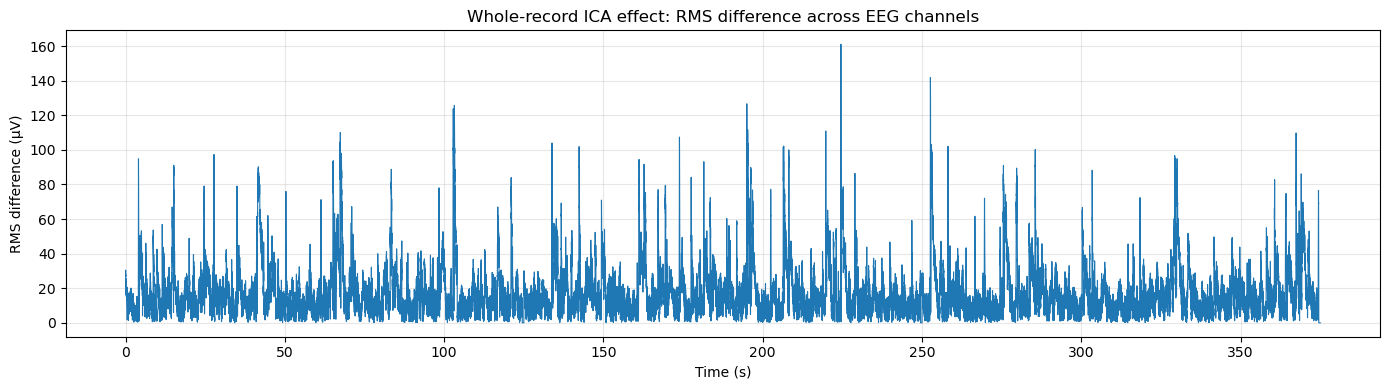

Saved to: D:\eeg-motor-imagery-mne-demo\results\06b_ica_whole_record_difference.png
File exists: True


In [45]:
%matplotlib inline

before = raw_ref.copy().pick("eeg")
after = raw_ica_clean.copy().pick("eeg")

data_before = before.get_data() * 1e6
data_after = after.get_data() * 1e6

diff = data_before - data_after
diff_rms = np.sqrt(np.mean(diff ** 2, axis=0))

times = before.times

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(times, diff_rms, linewidth=0.8)
ax.set_title("Whole-record ICA effect: RMS difference across EEG channels")
ax.set_xlabel("Time (s)")
ax.set_ylabel("RMS difference (μV)")
ax.grid(True, alpha=0.3)

fig.tight_layout()

ica_diff_path = RESULTS_DIR / "06b_ica_whole_record_difference.png"
fig.savefig(ica_diff_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved to:", ica_diff_path)
print("File exists:", ica_diff_path.exists())

## 最终预处理：7–30 Hz 带通滤波

运动想象 EEG 通常关注两个频段：

- mu rhythm: 8–13 Hz
- beta rhythm: 13–30 Hz

因此这里对 `raw_ica_clean` 进行 7–30 Hz 带通滤波，得到后续用于 epoch 切分和分类准备的 `raw_clean_filt`。

注意：

- `raw_clean_filt` 是从 `raw_ica_clean` 复制出来的新对象
- 不会修改 `raw_original`
- 不会修改 `raw_ref`
- 不会修改 `raw_ica_clean`
- `filter(l_freq=7.0, h_freq=30.0)` 本身就是带通滤波，不需要拆成高通和低通两步

In [47]:
print("raw_ica_clean exists:", "raw_ica_clean" in globals())

print(raw_ica_clean)
print("Data loaded:", raw_ica_clean.preload)
print("Duration seconds:", raw_ica_clean.times[-1])
print("Sampling rate:", raw_ica_clean.info["sfreq"])
print("Channels:", len(raw_ica_clean.ch_names))

raw_ica_clean exists: True
<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>
Data loaded: True
Duration seconds: 374.99375
Sampling rate: 160.0
Channels: 64


In [48]:
import time

print("Start 7-30 Hz band-pass filtering...")
print("This may take a while. Please wait.")

start_time = time.time()

raw_clean_filt = raw_ica_clean.copy().load_data()

print("Copy created.")
print(raw_clean_filt)

raw_clean_filt.filter(
    l_freq=7.0,
    h_freq=30.0,
    fir_design="firwin",
    skip_by_annotation="edge",
    verbose=True
)

end_time = time.time()

print("Filtering finished.")
print(f"Elapsed time: {end_time - start_time:.2f} seconds")
print(raw_clean_filt)

Start 7-30 Hz band-pass filtering...
This may take a while. Please wait.
Copy created.
<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Filtering finished.
Elapsed time: 0.17 seconds
<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>


## 可视化：7–30 Hz 滤波后的 EEG

这里查看最终预处理后的连续 EEG 信号。

这份数据已经经过：

1. standard_1005 电极位置设置
2. 平均参考
3. 可选 ICA 清理
4. 7–30 Hz 带通滤波

## 交互式双窗口对比：滤波前 vs 滤波后

这里打开两个交互式 EEG 浏览窗口：

- 滤波前：`raw_ica_clean`
- 滤波后：`raw_clean_filt`

你可以把两个窗口手动拖到左右并排，对比 7–30 Hz 滤波前后的变化。

说明：

- 处理作用于完整数据
- 窗口只是从指定时间点开始显示一小段
- 可以在窗口中滚动查看完整时间范围

In [49]:
%matplotlib qt

raw_ica_clean.copy().pick("eeg").plot(
    start=100,
    duration=5,
    n_channels=20,
    scalings="auto",
    block=False,
    title="滤波前：raw_ica_clean"
)

raw_clean_filt.copy().pick("eeg").plot(
    start=100,
    duration=5,
    n_channels=20,
    scalings="auto",
    block=False,
    title="滤波后：raw_clean_filt 7–30 Hz"
)

print("滤波前后两个交互窗口已打开，请手动拖到左右并排对比。")

滤波前后两个交互窗口已打开，请手动拖到左右并排对比。


## PSD 对比：滤波前 vs 滤波后

PSD 是功率谱密度，用来查看 EEG 在不同频率上的能量分布。

这里比较 7–30 Hz 滤波前后的频谱变化。

滤波后：

- 7 Hz 以下的低频成分应明显减少
- 30 Hz 以上的高频成分应明显减少
- 7–30 Hz 范围内的运动想象相关节律被保留

Saved to: D:\eeg-motor-imagery-mne-demo\results\09_filter_psd_comparison.png
File exists: True


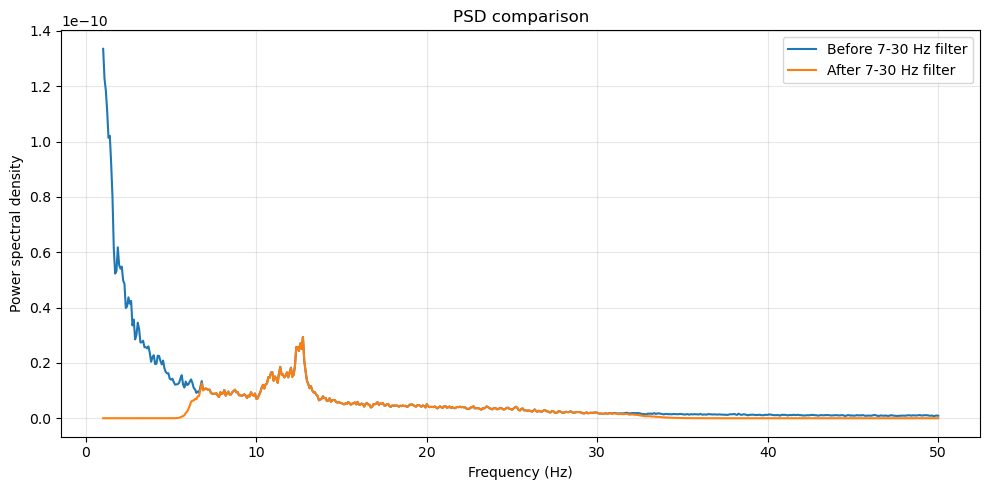

In [50]:
%matplotlib inline

plot_psd_compare(
    raw_ica_clean,
    raw_clean_filt,
    before_label="Before 7-30 Hz filter",
    after_label="After 7-30 Hz filter",
    fmin=1,
    fmax=50,
    save_name="09_filter_psd_comparison.png"
)

## 提取 T1 / T2 事件

EEGBCI 数据的 annotations 中包含 T0、T1、T2 三类标记。

在 runs 6、10、14 中：

- T0 = 休息
- T1 = imagined both fists
- T2 = imagined both feet

本项目只提取 T1 和 T2，用于后续构建 imagined both fists vs imagined both feet 的 epochs。

In [51]:
events, event_dict = mne.events_from_annotations(
    raw_clean_filt,
    event_id={
        "T1": 2,
        "T2": 3,
    },
    verbose=True
)

print("Event dictionary:", event_dict)
print("Events shape:", events.shape)
print("First 10 events:")
print(events[:10])

Used Annotations descriptions: [np.str_('T1'), np.str_('T2')]
Event dictionary: {np.str_('T1'): 2, np.str_('T2'): 3}
Events shape: (45, 3)
First 10 events:
[[  672     0     3]
 [ 2000     0     2]
 [ 3328     0     2]
 [ 4656     0     3]
 [ 5984     0     2]
 [ 7312     0     3]
 [ 8640     0     3]
 [ 9968     0     2]
 [11296     0     2]
 [12624     0     3]]


## 可视化：事件分布

这里查看 T1 / T2 事件在时间轴上的分布。

这一步可以确认事件是否成功提取，以及两个类别是否都存在。

Saved to: D:\eeg-motor-imagery-mne-demo\results\10_events_distribution.png
File exists: True


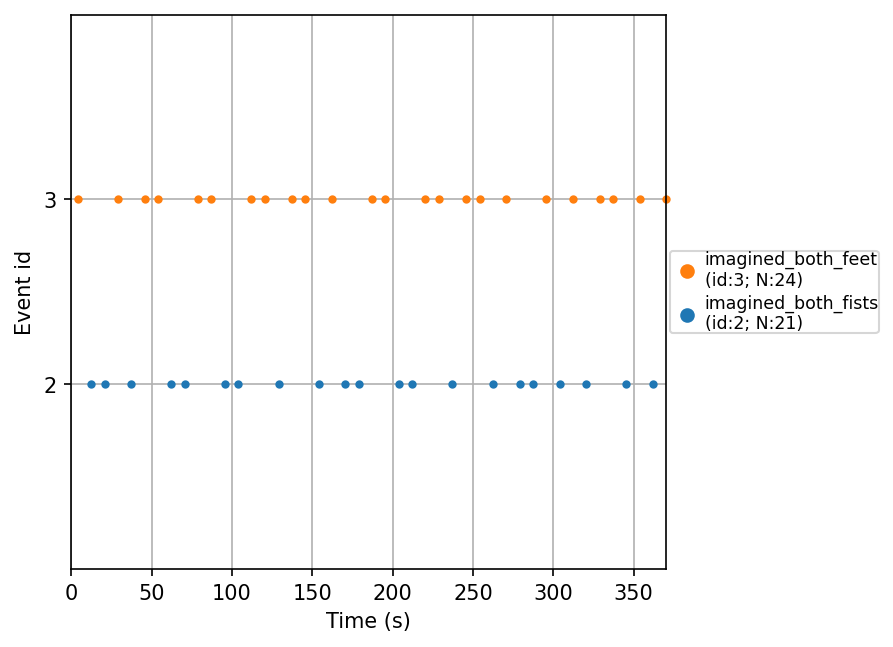

In [52]:
%matplotlib inline

fig = mne.viz.plot_events(
    events,
    sfreq=raw_clean_filt.info["sfreq"],
    first_samp=raw_clean_filt.first_samp,
    event_id={
        "imagined_both_fists": 2,
        "imagined_both_feet": 3,
    },
    show=False
)

events_path = RESULTS_DIR / "10_events_distribution.png"
fig.savefig(events_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print("Saved to:", events_path)
print("File exists:", events_path.exists())

display(Image(filename=str(events_path)))

## 切分 Epochs

Raw 是连续 EEG 信号。

Epoch 是根据事件标记切出来的一小段 trial。

这里每个 trial 取 cue 出现后的 0.5 秒到 2.5 秒。

也就是说：

- 每一个 T1 事件会生成一个 imagined both fists epoch
- 每一个 T2 事件会生成一个 imagined both feet epoch

完成这一步后，信号就已经整理成后续分类模型可以使用的 trial 形式。

In [53]:
EVENT_ID = {
    "imagined_both_fists": 2,
    "imagined_both_feet": 3,
}

epochs = mne.Epochs(
    raw_clean_filt,
    events,
    event_id=EVENT_ID,
    tmin=0.5,
    tmax=2.5,
    baseline=None,
    preload=True,
    reject_by_annotation=True,
    verbose=True
)

epochs

Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 321 original time points ...
0 bad epochs dropped


<Epochs | 45 events (all good), 0.5 – 2.5 s (baseline off), ~7.1 MiB, data loaded,
 'imagined_both_fists': 21
 'imagined_both_feet': 24>

## 交互式查看 Epochs

这里打开 MNE 的交互式 Epochs 浏览器。

每个 epoch 对应一次 imagined both fists 或 imagined both feet trial。

你可以检查：

- 是否存在明显异常的 trial
- epochs 是否切分正确
- 不同 trial 的 EEG 波形是否合理

In [54]:
%matplotlib qt

epochs.plot(
    n_epochs=10,
    n_channels=20,
    scalings="auto",
    block=False
)

print("Epochs 交互窗口已打开。")

Epochs 交互窗口已打开。


## 可视化：Epochs Image

Epochs image 可以查看每个 trial 随时间变化的信号模式。

这里以 Cz 通道为例，检查所有 epochs 在该通道上的时间序列分布。

Saved to: D:\eeg-motor-imagery-mne-demo\results\11_epochs_image_cz.png
File exists: True


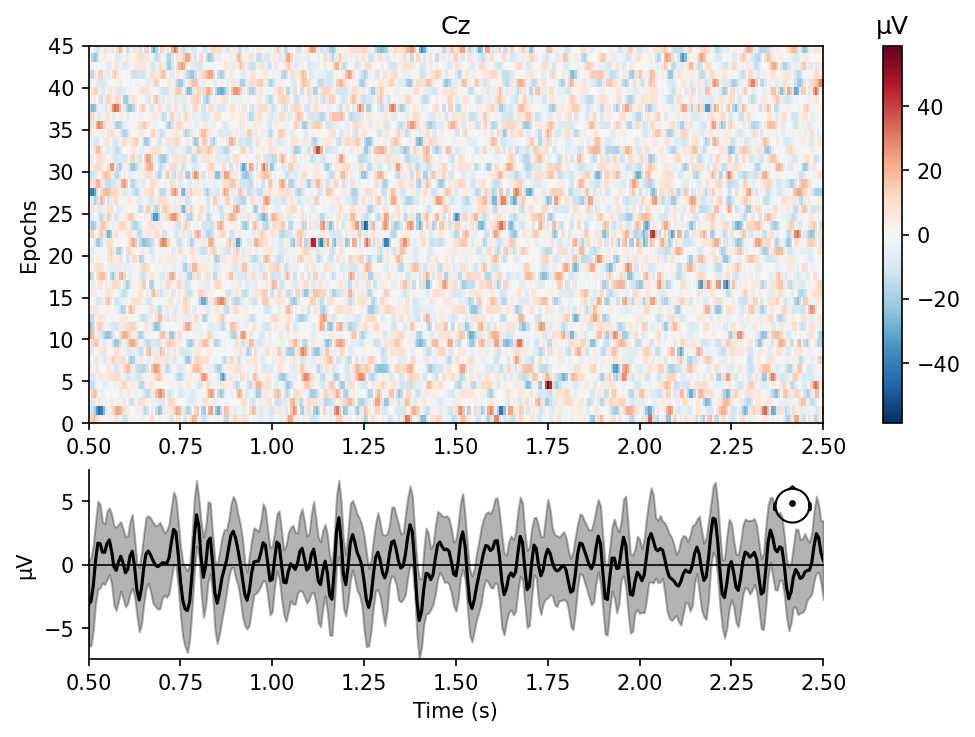

In [55]:
%matplotlib inline

fig = epochs.plot_image(
    picks=["Cz"],
    combine=None,
    show=False
)

fig_to_save = fig[0] if isinstance(fig, list) else fig

epochs_image_path = RESULTS_DIR / "11_epochs_image_cz.png"
fig_to_save.savefig(epochs_image_path, dpi=150, bbox_inches="tight")
plt.close(fig_to_save)

print("Saved to:", epochs_image_path)
print("File exists:", epochs_image_path.exists())

display(Image(filename=str(epochs_image_path)))

## 查看预处理后的数据形状

这里把 epochs 转换成后续机器学习模型可以直接使用的数据格式。

`X` 是 EEG 数据：

```text
n_epochs × n_channels × n_times

In [57]:
## Code 单元格：生成 X 和 y
X = epochs.get_data()
y = epochs.events[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Label counts:", np.unique(y, return_counts=True))

X shape: (45, 64, 321)
y shape: (45,)
Label counts: (array([2, 3]), array([21, 24]))


## 保存预处理后的 Epochs 文件

这里将预处理后的 epochs 保存为 `.fif` 文件，方便后续直接加载使用。

注意：

这个 `.fif` 文件是本地中间结果，不建议上传到 GitHub。

GitHub 仓库中应通过 `.gitignore` 忽略：

```text
*.fif
processed/

In [58]:

## Code 单元格：保存 epochs

PROCESSED_DIR = PROJECT_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

epochs_path = PROCESSED_DIR / "s001_imagined_fists_feet_preprocessed-epo.fif"

epochs.save(
    epochs_path,
    overwrite=True
)

print("Saved preprocessed epochs to:", epochs_path)
print("File exists:", epochs_path.exists())

Saved preprocessed epochs to: D:\eeg-motor-imagery-mne-demo\processed\s001_imagined_fists_feet_preprocessed-epo.fif
File exists: True


## 检查预处理结果文件

这里检查 `results` 文件夹中生成的所有图片。

这些图片可以用于 GitHub README 或项目展示。

In [59]:
result_files = sorted(RESULTS_DIR.glob("*.png"))

print("Results folder:", RESULTS_DIR)
print()

for path in result_files:
    print(path.name, "-", path.stat().st_size, "bytes")

print()
print("Total result files:", len(result_files))

Results folder: D:\eeg-motor-imagery-mne-demo\results

03_reference_comparison_cz.png - 213889 bytes
04_reference_psd_comparison.png - 62649 bytes
05_ica_highpass_comparison_cz.png - 273013 bytes
06b_ica_whole_record_difference.png - 120446 bytes
09_filter_psd_comparison.png - 61827 bytes
10_events_distribution.png - 21636 bytes
11_epochs_image_cz.png - 142272 bytes
raw_eeg_sample.png - 737082 bytes

Total result files: 8
